In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('indian_liver_patient.csv')
df

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [3]:
#checking if the dataset has null values
null_columns = df.isnull().any()
print("Columns with null values:")
print(null_columns[null_columns].index.tolist())

Columns with null values:
['Albumin_and_Globulin_Ratio']


In [4]:
#handling missing value, by filling them with the mean of the same column
df['Albumin_and_Globulin_Ratio'] = df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].mean())

In [5]:
#checking if all the missing values were filled successfully
df['Albumin_and_Globulin_Ratio'].isnull().any()

False

In [6]:
# Convert the 'Gender' column into dummy variables
df = pd.get_dummies(df, columns=['Gender'], drop_first=True,dtype=int)

In [7]:
df['Gender_Male']

0      0
1      1
2      1
3      1
4      1
      ..
578    1
579    1
580    1
581    1
582    1
Name: Gender_Male, Length: 583, dtype: int32

In [8]:
#normalization for the data in the range 0-1
scaler = MinMaxScaler()
numerical_columns = df.drop('Dataset', axis=1).columns  # Exclude target column
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
df.head()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset,Gender_Male
0,0.709302,0.004021,0.000000,0.060576,0.003015,0.001626,0.594203,0.521739,0.240,1,0.0
1,0.674419,0.140751,0.275510,0.310699,0.027136,0.018296,0.695652,0.500000,0.176,1,1.0
2,0.674419,0.092493,0.204082,0.208598,0.025126,0.011791,0.623188,0.521739,0.236,1,1.0
3,0.627907,0.008043,0.015306,0.058134,0.002010,0.002033,0.594203,0.543478,0.280,1,1.0
4,0.790698,0.046917,0.096939,0.064485,0.008543,0.009961,0.666667,0.326087,0.040,1,1.0


In [9]:
# Calculate the standard deviation for the selected features
df_std_deviation = df.std()

df_std_deviation


Age                           0.188254
Total_Bilirubin               0.083238
Direct_Bilirubin              0.143291
Alkaline_Phosphotase          0.118680
Alamine_Aminotransferase      0.091769
Aspartate_Aminotransferase    0.058735
Total_Protiens                0.157312
Albumin                       0.172939
Albumin_and_Globulin_Ratio    0.127397
Dataset                       0.452490
Gender_Male                   0.429603
dtype: float64

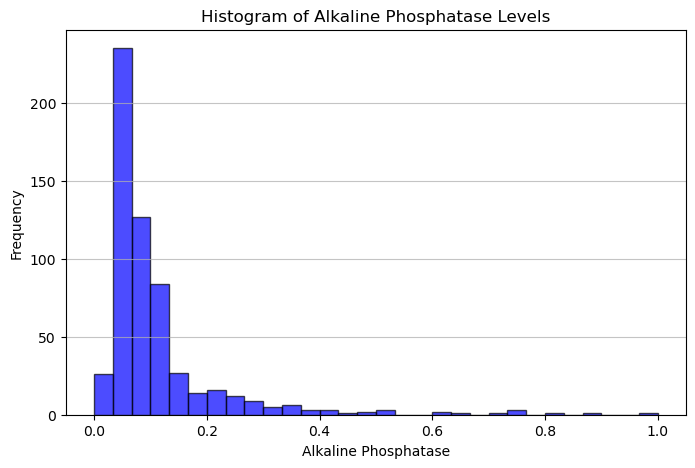

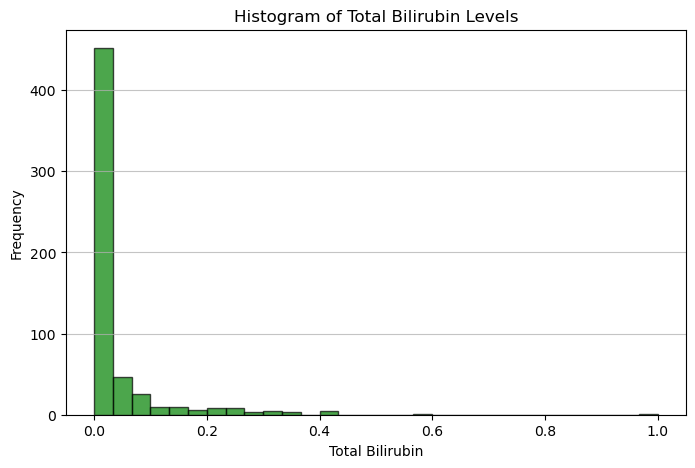

In [10]:
import matplotlib.pyplot as plt

# Plot histogram for Alkaline_Phosphotase
plt.figure(figsize=(8, 5))
plt.hist(df['Alkaline_Phosphotase'], bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Alkaline Phosphatase Levels')
plt.xlabel('Alkaline Phosphatase')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Plot histogram for Total_Bilirubin
plt.figure(figsize=(8, 5))
plt.hist(df['Total_Bilirubin'], bins=30, color='green', edgecolor='black', alpha=0.7)
plt.title('Histogram of Total Bilirubin Levels')
plt.xlabel('Total Bilirubin')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [11]:
#preform featcherselection

In [12]:
# Compute the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
print(correlation_matrix)


                                 Age  Total_Bilirubin  Direct_Bilirubin  \
Age                         1.000000         0.011763          0.007529   
Total_Bilirubin             0.011763         1.000000          0.874618   
Direct_Bilirubin            0.007529         0.874618          1.000000   
Alkaline_Phosphotase        0.080425         0.206669          0.234939   
Alamine_Aminotransferase   -0.086883         0.214065          0.233894   
Aspartate_Aminotransferase -0.019910         0.237831          0.257544   
Total_Protiens             -0.187461        -0.008099         -0.000139   
Albumin                    -0.265924        -0.222250         -0.228531   
Albumin_and_Globulin_Ratio -0.216089        -0.206159         -0.200004   
Dataset                    -0.137351        -0.220208         -0.246046   
Gender_Male                 0.056560         0.089291          0.100436   

                            Alkaline_Phosphotase  Alamine_Aminotransferase  \
Age                  

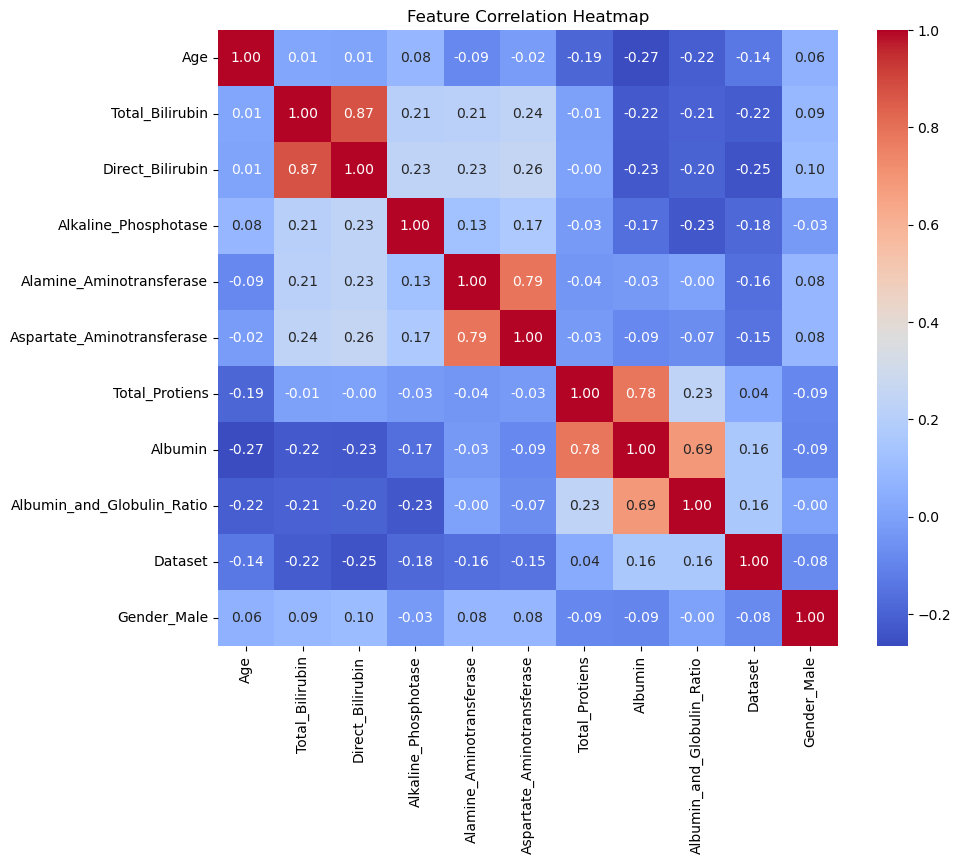

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Heatmap")
plt.show()


In [14]:
# Identify correlations with the target variable
target_correlations = correlation_matrix['Dataset'].sort_values(ascending=False)
print(target_correlations)

# Set a threshold for high correlations (e.g., |correlation| > 0.2)
highly_correlated_features = target_correlations[abs(target_correlations) > 0.2].index
print("Highly correlated features with the target:", highly_correlated_features)


Dataset                       1.000000
Albumin_and_Globulin_Ratio    0.162319
Albumin                       0.161388
Total_Protiens                0.035008
Gender_Male                  -0.082416
Age                          -0.137351
Aspartate_Aminotransferase   -0.151934
Alamine_Aminotransferase     -0.163416
Alkaline_Phosphotase         -0.184866
Total_Bilirubin              -0.220208
Direct_Bilirubin             -0.246046
Name: Dataset, dtype: float64
Highly correlated features with the target: Index(['Dataset', 'Total_Bilirubin', 'Direct_Bilirubin'], dtype='object')


In [15]:
# List of selected features (excluding the target variable)
selected_features = ['Albumin_and_Globulin_Ratio', 'Albumin', 'Total_Bilirubin', 'Direct_Bilirubin']  
df_selected = df[selected_features + ['Dataset']]


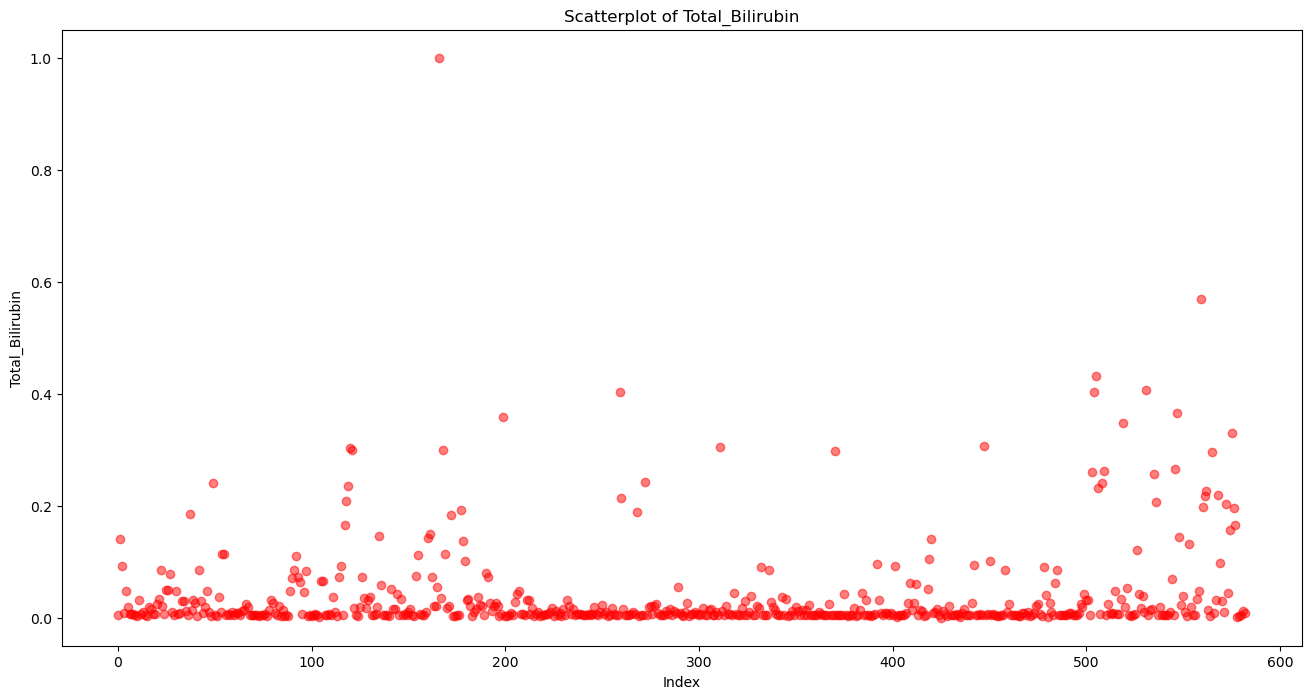

In [16]:
# Extract the 'Total_Bilirubin' column
total_bilirubin = df_selected['Total_Bilirubin']

# Create a list of consecutive integers as x-values
integers = range(len(total_bilirubin))

# Plot the scatterplot
plt.figure(figsize=(16, 8))
plt.scatter(integers, total_bilirubin, c='red', alpha=0.5)
plt.title('Scatterplot of Total_Bilirubin')
plt.xlabel('Index')
plt.ylabel('Total_Bilirubin')
plt.show()

In [17]:
#Random Forest Model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score


# Assuming df_selected is already created with feature selection and target column included
# Split data into features (X) and target (y)
X = df_selected.drop('Dataset', axis=1)
y = df_selected['Dataset']

# Split into training and testing datasets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest classifier and handling class imbalance 
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced' )


# Fit the model to the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_classifier.predict(X_test)

# Generate the classification report to view precision, recall, f1-score, and support
report = classification_report(y_test, y_pred)
print(report)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nRandom Forest Accuracy:", accuracy)

              precision    recall  f1-score   support

           1       0.77      0.80      0.79        87
           2       0.35      0.30      0.32        30

    accuracy                           0.68       117
   macro avg       0.56      0.55      0.55       117
weighted avg       0.66      0.68      0.67       117


Random Forest Accuracy: 0.6752136752136753


In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# Step 1: Define the Parameter Grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': [None, 'sqrt']
}

# Step 2: Initialize the Random Forest classifier and GridSearchCV
rf = RandomForestClassifier(random_state=42)

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=2)

# Step 3: Fit the grid search to the training data (you already have X_train and y_train)
grid_search.fit(X_train, y_train)

# Step 4: Evaluate the Best Model
# Get the best hyperparameters found by Grid Search
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Use the best model to make predictions on the test data
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Generate the classification report
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
              precision    recall  f1-score   support

           1       0.79      0.82      0.80        87
           2       0.41      0.37      0.39        30

    accuracy                           0.70       117
   macro avg       0.60      0.59      0.59       117
weighted avg       0.69      0.70      0.70       117



In [19]:
#Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Step 1: Initialize the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Step 2: Fit the model to the training data
dt_model.fit(X_train, y_train)

# Step 3: Make predictions on the test data
y_pred_dt = dt_model.predict(X_test)

# Step 4: Evaluate the model
print("Classification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dt))

# Print accuracy
accuracy = accuracy_score(y_test, y_pred_dt)
print("\nDecision Tree Accuracy:", accuracy)


Classification Report for Decision Tree:
              precision    recall  f1-score   support

           1       0.80      0.80      0.80        87
           2       0.41      0.40      0.41        30

    accuracy                           0.70       117
   macro avg       0.60      0.60      0.60       117
weighted avg       0.70      0.70      0.70       117


Decision Tree Accuracy: 0.7008547008547008


In [20]:
from sklearn.model_selection import GridSearchCV

# Step 1: Define the parameter grid
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Step 2: Initialize the Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Step 3: Perform Grid Search
grid_search_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, 
                              cv=3, n_jobs=-1, verbose=2)

# Fit the GridSearchCV to the training data
grid_search_dt.fit(X_train, y_train)

# Step 4: Get the best parameters and evaluate
best_params_dt = grid_search_dt.best_params_
print("Best Parameters for Decision Tree:", best_params_dt)

# Use the best model to make predictions
best_dt = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

# Generate the classification report
print("Classification Report for Tuned Decision Tree:")
print(classification_report(y_test, y_pred_best_dt))


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Classification Report for Tuned Decision Tree:
              precision    recall  f1-score   support

           1       0.75      0.91      0.82        87
           2       0.33      0.13      0.19        30

    accuracy                           0.71       117
   macro avg       0.54      0.52      0.51       117
weighted avg       0.64      0.71      0.66       117



In [21]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression

# Define logistic regression model with class imbalance handling
log_reg = LogisticRegression(random_state=42, class_weight='balanced')

# Fit the logistic regression model (without hyperparameter tuning)
log_reg.fit(X_train, y_train)

# Use the model to make predictions on the test set
y_pred = log_reg.predict(X_test)

# Print accuracy
from sklearn.metrics import accuracy_score, classification_report


print("\nClassification Report (Logistic Regression Without Hyperparameter Tuning):")
print(classification_report(y_test, y_pred, zero_division=0))
print("\nLogistic Regression Accuracy (Without Hyperparameter Tuning):", accuracy_score(y_test, y_pred))



Classification Report (Logistic Regression Without Hyperparameter Tuning):
              precision    recall  f1-score   support

           1       0.90      0.49      0.64        87
           2       0.36      0.83      0.51        30

    accuracy                           0.58       117
   macro avg       0.63      0.66      0.57       117
weighted avg       0.76      0.58      0.60       117


Logistic Regression Accuracy (Without Hyperparameter Tuning): 0.5811965811965812


In [22]:
# Import necessary libraries
from sklearn.model_selection import GridSearchCV

# Define hyperparameters and solvers for GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Perform GridSearchCV
grid_search = GridSearchCV(LogisticRegression(random_state=42, class_weight='balanced'), 
                           param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best parameters and cross-validation score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

# Show textual details of the best logistic regression model
best_model = grid_search.best_estimator_
print("\nBest Logistic Regression Model:")
print(best_model)

# Use the best model to make predictions on the test set
y_pred_best = best_model.predict(X_test)

# Generate the classification report and handle the UndefinedMetricWarning
print("\nClassification Report (Best Logistic Regression Model):")
print(classification_report(y_test, y_pred_best, zero_division=0))

# Print accuracy
accuracy = accuracy_score(y_test, y_pred_best)
print("\nLogistic Regression Accuracy (After Hyperparameter Tuning):", accuracy)


Best Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.7060169297643561

Best Logistic Regression Model:
LogisticRegression(C=0.01, class_weight='balanced', penalty='l1',
                   random_state=42, solver='liblinear')

Classification Report (Best Logistic Regression Model):
              precision    recall  f1-score   support

           1       0.74      1.00      0.85        87
           2       0.00      0.00      0.00        30

    accuracy                           0.74       117
   macro avg       0.37      0.50      0.43       117
weighted avg       0.55      0.74      0.63       117


Logistic Regression Accuracy (After Hyperparameter Tuning): 0.7435897435897436
